<a href="https://colab.research.google.com/github/lexmar07/Deep-Legendre-Transform/blob/main/NIPS_ConvexConjugates_experiment_in_Rd.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Convex conjugation plays an important role in convex duality theory.
For a subset $C \subseteq  \mathbb{R} ^d$, let us denote by
$\delta_C \colon \mathbb{R} ^d \to \mathbb{R}  \cup \{+\infty\}$ the indicator function
given by
$$
\delta_C(x) := \begin{cases} 0 & \mbox{ if } x \in C\\
+ \infty & \mbox{ if } x \notin C.
\end{cases}
$$
For a function $f \colon \mathbb{R} ^d \to \mathbb{R} \cup \{+ \infty\}$, we denote by
$f_C^* \colon  \mathbb{R}  \cup \{+ \infty\}$ the convex conjugate of $f + \delta_C$ given by
$$
f_C^*(y) := \sup_{x \in C} { \langle x , y\rangle - f(x) }.
$$

**For example,** Hamiltonian in economic applications can be computed

$$H(p) = \max_c\{ p^Tc + u(c)\},$$

where $u$ is the (concave) utility function and $c$ stands for the consumption bundle.

Since function $f$ is assumed convex, there are two possible **direct** approaches:

1. Calculate FOCs (generally, subradients) of $f$ + solve corresponding equations

2. Realize maximization procedure directly: use stochastic gradient descent to evaluate $f_C^*(y)$.

These approaches are inefficient.


**Idea 3.** In the special case, where $f \colon C \to \R$ is a differentiable convex function
on an open convex set $C \subseteq R^d$, one has  
$$
f^*(y) = \langle(\nabla f)^{-1}(y), y\rangle  - f((\nabla f)^{-1}(y))
$$
for all $y \in D = \nabla f(C).$

The right side of the equation is called Legendre transform. In fact, it follows from the Fenchel--Young inequality
that if $f$ is differentiable and convex, $\langle x, y\rangle - f(x)$ is the same for all
$x$ in the pre-image $(\nabla f)^{-1}(y)$. So $(\nabla f)^{-1}(y)$
can be substituted with any $x \in C$ satisfying $\nabla f(x) = y$.



## Simplest example:

We first consider the quadratic function $f \colon R^d \to R$ given by
$$
f(x) = \langle x , x\rangle  = x^2_1 + \dots + x^2_d.
$$
It is well known (and can easily be checked) that $f^* = f/4$.

To approximate $f^*$ numerically, we generated $X_{test}$ by sampling
approximately $10^4$ points $x \in R^d$ from a $d$-dimensional standard normal
distribution $N(0, I_d)$.

Libraries: JAX.

In [ ]:
# !pip install optax

In [ ]:
import numpy as np
import jax
import jax.numpy as jnp
from jax import random, vmap, lax
from jax.tree_util import tree_leaves

import optax
import matplotlib.pyplot as plt
import yaml
import os
import time
import sys
import json
from scipy.io import savemat
from tqdm import tqdm
from collections import namedtuple
from functools import partial
from typing import Callable, Any, List

# Flax library imports
from flax import linen as nn
from flax.training import train_state



In [ ]:
base_path = "/content/drive/MyDrive/ETH/Convex_conjugates/experiments_with_ICNN_3"
sys.path.append(base_path)

from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Primal QUADRATIC:
def quadratic(x):
    return jnp.reshape(jnp.sum(x*x, -1), ())
# Dual:
quadratic_star_true = lambda x: jnp.sum(x*x, -1) / 4


In [ ]:
# Identity function for compatability with NN:
def G_ID(v, beta):
    return beta * v

# Square function to ensure non-negativity of ICNN weights (squares the input scaled by beta):
def G_SQUARE(v, beta):
    return jnp.square(beta * v)


In [ ]:
class NonNegativeDense(nn.Module):
    features: int
    use_bias: bool = True
    dtype: Any = None
    kernel_init: Callable = nn.initializers.lecun_normal()
    bias_init: Callable = nn.initializers.zeros
    pre_transform: Callable = jnp.square # Optional pre-transformation

    @nn.compact
    def __call__(self, inputs):
        kernel_shape = (inputs.shape[-1], self.features)
        kernel = self.param('kernel', self.kernel_init, kernel_shape)
        # if self.pre_transform:
        kernel = self.pre_transform(kernel)  # Apply pre-transformation if any
         # Squaring the kernel to ensure non-negative weights
        y = jnp.dot(inputs, kernel)
        if self.use_bias:
            bias = self.param('bias', self.bias_init, (self.features,))
            y += bias
        return y

class ConvexNN(nn.Module):
    layer_widths: List[int]
    activation: Callable = nn.relu  # Default activation; adjust as needed

    @nn.compact
    def __call__(self, x):
        # Adjust to handle specific transformations for the first and last layers if needed
        for i, width in enumerate(self.layer_widths):
            # Use NonNegativeDense with optional pre_transform for the last layer
            if i == 0:  # First layer, using standard nn.Dense
                x = nn.Dense(features=width)(x)
            else:  # Intermediate layers with NonNegativeDense without pre_transform
                x = NonNegativeDense(features=width)(x)
            x = self.activation(x)

        # Final output layer, assuming a single output unit for simplicity
        x = NonNegativeDense(features=1)(x)  # Adjust if different behavior is desired
        return x


# Configuration Parameters

- **experiment_name**: A string used to uniquely identify and track the experiment.
- **description**: A string describing the purpose or details of the experiment.
- **dim**: An integer representing the dimensionality of the input space.
- **layer_widths**: A list of integers specifying the number of units in each layer of the neural network.
- **num_epochs**: An integer representing the number of epochs to train the model.
- **batch_size**: An integer specifying the size of each training batch.
- **steps**: An integer representing the number of steps the model takes per batch, relevant when mini-batch optimization is used (i.e., when `use_grid` is False).
- **start**: A float or list of floats representing the start point(s) of the rectangular domain for the primal variables \( x \).
- **end**: A float or list of floats representing the end point(s) of the rectangular domain for the primal variables \( x \).
- **convrg_eps**: A float specifying the convergence threshold epsilon for stopping the training.
- **learning_rate**: A float representing the learning rate for the optimizer.
- **l2_regularization_coefficient**: A float for the L2 regularization term to prevent overfitting.
- **N_ae**: An integer specifying the number of epochs for pretraining an autoencoder, if applicable.
- **v_init_fn**: A callable function for initializing the parameters. For instance, it could be a function that generates random values within a certain range.
- **minval**: A float or list of floats indicating the minimum value(s) for the gradient domain, corresponding to the dual variables \( y \).
- **maxval**: A float or list of floats indicating the maximum value(s) for the gradient domain, corresponding to the dual variables \( y \).
- **y_func**: A callable function defining the behavior or computation of the dual variables \( y \).
- **y_func_star**: A callable function representing the true conjugate of \( y \).

## Domain Explanation

- **Primal Domain (`start` to `end`)**: The domain for the primal variables \( x \) is defined as \([start, end]^d\).
- **Dual Domain (`minval` to `maxval`)**: The domain for the dual variables \( y \) is defined as \([minval, maxval]^d\).

The correct transformation between the domains is $\nabla f: H \to K$  and $\nabla^{-1} f: K\to H$ realized below with approximate inverse mappings.

In [ ]:
LEARNING_RATE = 3e-4
ALPHA = 1e-8 #

Config = namedtuple("Config",
                    [
                     "experiment_name",        # Name of the experiment for tracking purposes
                     "description",            # Description of the experiment
                     "dim",                    # Dimensionality of the input space
                     "layer_widths",           # Widths of each layer in the neural network
                     "num_epochs",             # Number of epochs for training
                     "batch_size",             # Batch size for training
                     "steps",                  # Number of steps per batch (useful if use_grid is False)
                     "start",                  # Start point of the primal domain (rectangular domain start)
                     "end",                    # End point of the primal domain (rectangular domain end)
                     "convrg_eps",             # Convergence epsilon for stopping criterion
                     "learning_rate",          # Starting value of the learning rate for the optimizer
                     "N_ae",                   # Number of epochs for autoencoder pretraining
                     "v_init_fn",              # Initialization function for the parameters
                     "minval",                 # Minimum value for the gradient domain (dual domain start)
                     "maxval",                 # Maximum value for the gradient domain (dual domain end)
                     "f_func",                 # Function definition for y (dual variables)
                     "f_func_star"             # True function conjugate for y
                    ])



In [ ]:
# Map the string names to the actual functions
function_mapping = {
    "G_SQUARE": G_SQUARE,# g_fn
    "G_ID": G_ID,# g_fn
    "quadratic": quadratic,
    "quadratic_star_true" : quadratic_star_true,
    # Add other functions...
}

# Some saving/loading utils:

In [ ]:
def save_statistics(statistics, path_to_save, filename):
    # Convert JAX arrays to NumPy arrays, NumPy arrays to lists, and float32 to float
    serializable_stats = {}
    for k, v in statistics.items():
        if isinstance(v, (jnp.ndarray, np.ndarray)):
            v = jax.device_get(v).tolist()
        elif isinstance(v, np.float32):
            v = float(v)
        serializable_stats[k] = v

    print("Statistics:")
    for key, value in statistics.items():
        print(f"  {key}: {value}")

    full_path = os.path.join(path_to_save, filename)
    with open(full_path, 'w') as file:
        json.dump(serializable_stats, file)


In [ ]:
def save_config_to_yaml(config, path):
    # Ensure the directory exists
    os.makedirs(os.path.dirname(path), exist_ok=True)
    with open(path, 'w') as file:
        yaml.dump(dict(config._asdict()), file)

# Some plotting/statistics utils:

In [ ]:
def plot_results(d, eval_grad_f_x, preds, vmap_f_star_true, state, const_val, Loss):
    """
    Plots evaluation results and calculates residuals.

    Args:
        d (int): Dimensionality of the input space.
        eval_grad_f_x (array): Evaluated gradient values.
        preds (array): Predictions from the model.
        vmap_f_star_true (callable): Function to compute true conjugate values.
        state (train_state.TrainState): Training state containing model parameters.
        const_val (float): Constant value for plotting higher dimensions.
        Loss (list): List of loss values over epochs.
    """
    if d == 1:
        # Sort and plot for 1D
        eval_grad_f_x = np.squeeze(eval_grad_f_x)
        indices = np.argsort(eval_grad_f_x)
        eval_grad_f_x, preds = eval_grad_f_x[indices], preds.flatten()[indices].reshape(-1, 1)
        plt.plot(eval_grad_f_x, preds, lw=3, label='Predictions')
        plt.plot(eval_grad_f_x, vmap_f_star_true(eval_grad_f_x.reshape(-1, 1)), lw=1, label='True Conjugate')
        plt.xlabel('eval_grad_f_x')
        plt.ylabel('Function Values')
        plt.title('Sorted Points and Function Values')
        plt.legend()
        plt.grid(True)
        plt.show()

        # Calculate and print RMSE (residual)
        accuracy = 1 / np.sqrt(eval_grad_f_x.shape[0]) * jnp.linalg.norm(preds.reshape(-1, 1) - vmap_f_star_true(eval_grad_f_x).reshape(-1, 1))
        print("Residual:", accuracy)

    if d >= 2:
        # Scatter plot for first two components in 2D+
        start = jnp.min(eval_grad_f_x)
        end = jnp.max(eval_grad_f_x)
        plt.figure()
        plt.scatter(eval_grad_f_x[:, 0], eval_grad_f_x[:, 1], c='red', marker='o')
        plt.xlabel('Component 0 of eval_grad_f_x')
        plt.ylabel('Component 1 of eval_grad_f_x')
        plt.title('Scatter Plot of First Two Components of eval_grad_f_x')
        plt.grid(True)
        plt.show()

        def generate_1D_line_in_dD_space(axis, const_val, start, end, num_points=100, d=d):
            x = jnp.linspace(start, end, num_points)
            line_dD = jnp.ones((num_points, d)) * const_val
            line_dD = line_dD.at[:, axis].set(x)
            return line_dD

        def calculate_and_plot(axis, const_val):
            line_dD = generate_1D_line_in_dD_space(axis, const_val, start, end)
            f_x = state.apply_fn({'params': state.params}, line_dD)
            f_star_true_x = vmap_f_star_true(line_dD)

            # Calculate and print RMSE along the axis
            accuracy = 1 / np.sqrt(line_dD.shape[0]) * jnp.linalg.norm(f_x.reshape(-1, 1) - f_star_true_x.reshape(-1, 1))
            print("Residual along axis {} @ value = {}: {}".format(axis, const_val, accuracy))

            plt.figure()
            plt.plot(line_dD[:, axis], f_x, label='f(x)')
            plt.plot(line_dD[:, axis], f_star_true_x, label='True Conjugate')
            plt.title('Numerical and Analytical Conjugate along axis {}'.format(axis))
            plt.legend()
            plt.grid(True)
            plt.show()

        calculate_and_plot(axis=0, const_val=const_val)
        calculate_and_plot(axis=1, const_val=const_val)

    # Plot training loss over epochs
    plt.figure()
    plt.plot(Loss, label='Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.title('Training Loss Over Epochs')
    plt.legend()
    plt.grid(True)
    plt.show()


In [ ]:
def descriptive_statistics(data, name="Data"):
    """Returns descriptive statistics for the given data as a dictionary."""
    data = np.array(data)
    mean = np.mean(data, axis=0)
    std_dev = np.std(data, axis=0)
    minimum = np.min(data, axis=0)
    maximum = np.max(data, axis=0)
    shape = data.shape

    statistics = {
        "name": name,
        "shape": shape,
        "mean": mean,
        "std_dev": std_dev,
        "min": minimum,
        "max": maximum
    }

    return statistics


In [ ]:
def calculate_statistics(eval_batch_x, eval_grad_f_x, preds, vmap_f_star_true, loss_value):
    """
    Calculate various statistics for evaluating the model's performance.

    Args:
        eval_batch_x (array): Batch of evaluation input data.
        eval_grad_f_x (array): Batch of gradient values.
        preds (array): Predictions from the model.
        vmap_f_star_true (callable): Function to compute true conjugate values.
        loss_value (float): The loss value from the model.

    Returns:
        acc (float): Root Mean Squared Error (RMSE) between predictions and true values, excluding infinities.
        max_acc (float): Maximum error between predictions and true values, excluding infinities.
        res (float): Square root of the loss value.
        mre (float): Mean Relative Error (MRE) between predictions and true values, excluding infinities.
    """
    # Calculate true conjugate values
    f_star_values = vmap_f_star_true(eval_grad_f_x)

    # Identify points where vmap_f_star_true gives infinity
    is_finite = jnp.isfinite(f_star_values)

    # Apply the mask to filter out infinite points
    finite_preds = preds[is_finite]
    finite_f_star_values = f_star_values[is_finite]

    # Reshape for calculation
    finite_preds_reshaped = finite_preds.reshape(-1, 1)
    finite_f_star_values_reshaped = finite_f_star_values.reshape(-1, 1)

    # Calculate RMSE excluding infinite points
    acc = 1 / np.sqrt(finite_preds_reshaped.shape[0]) * jnp.linalg.norm(finite_preds_reshaped - finite_f_star_values_reshaped)

    # Calculate maximum error excluding infinite points
    max_acc = jnp.max(jnp.abs(finite_preds_reshaped - finite_f_star_values_reshaped))

    # Calculate Mean Relative Error (MRE), avoiding division by zero
    relative_errors = jnp.where(finite_f_star_values_reshaped != 0,
                                jnp.abs((finite_preds_reshaped - finite_f_star_values_reshaped) / finite_f_star_values_reshaped),
                                0)
    mre = jnp.mean(relative_errors)

    # Calculate square root of the loss value
    res = np.sqrt(loss_value)

    return acc, max_acc, res, mre


# RUN **SINGLE** EXPERIMENT



In [ ]:
cfg = Config(
    experiment_name = "test",               # Name of the experiment for tracking purposes
    description = "test experiment",        # Description of the experiment
    dim = 5,                               # Dimensionality of the input space
    layer_widths = (128, 64, 64),           # Widths of each layer in the neural network
    num_epochs = 10000,                   # Number of epochs for training
    N_ae = 0,                           # Number of epochs for autoencoder pretraining
    batch_size = 3200,                      # Batch size for training; you should USE UP TO 10**6 in high-dimensions like d = 50, 100!!!
    steps = 2,                              # Number of steps per batch (useful if use_grid is False)
    start = None,                              # Start point of the primal domain (rectangular domain start point)
    end = None,                                # End point of the primal domain (rectangular domain end point)
    minval = None,                             # Minimum value for the gradient domain (dual domain start)
    maxval = None,                            # Maximum value for the gradient domain (dual domain end)
    convrg_eps = 1e-5,                      # Convergence epsilon for stopping criterion
    learning_rate = 3e-3,                   # Learning rate for the optimizer
    v_init_fn = "V_INIT_Uniform",           # Initialization function for the parameters
    f_func = "quadratic",            # Function definition for f (dual variables)
    f_func_star = "quadratic_star_true" # True function conjugate for f*
)


path_to_results_and_cfgs = os.path.join(base_path, "Experiment_test")

# Path to the YAML file
config_path = os.path.join(path_to_results_and_cfgs, 'config.yaml')

# Save the config to the YAML file
save_config_to_yaml(cfg, config_path)

### JAX tricks:

We vmap all the funcitons for efficient computing.

In [ ]:
initial_key = jax.random.PRNGKey(0)

f = function_mapping[cfg.f_func]
f_star_true =  function_mapping[cfg.f_func_star]

# Wrapping the modified objective function with grad, jit, and vmap
grad_f_fn = jax.grad(f, argnums=0)
grad_f = jax.jit(grad_f_fn)

# Vectorization for processing batches of inputs "vmap_f_epsilon"
vmap_grad_f = vmap(grad_f, in_axes = 0)
vmap_f = vmap(f, in_axes = 0)
vmap_f_star_true = vmap(f_star_true, in_axes = 0)


In [ ]:
# # Example training loop setup
n_samples = cfg.batch_size * 10
batch_size = cfg.batch_size


In [ ]:
# Function to generate random mini-batches
def create_uniform_x_samples_generator(cfg, key):
    while True:
        key, subkey = jax.random.split(key)
        U = jax.random.uniform(key=subkey, shape=(cfg.batch_size, cfg.dim), minval=cfg.start, maxval=cfg.end)
        yield U

@partial(jax.jit, static_argnums=(1, 2))
def generate_normal_samples(key, batch_size, d):
    mean = jnp.zeros(d)
    cov = jnp.eye(d)
    return jax.random.multivariate_normal(key, mean, cov, shape=(batch_size,))

def create_normal_samples_generator(cfg, key):
    while True:
        key, subkey = jax.random.split(key)
        normal_samples = generate_normal_samples(subkey, cfg.batch_size, cfg.dim)
        yield normal_samples



In [ ]:
initial_key = jax.random.PRNGKey(0)

# Assuming params and decoder_net are already defined
train_x_gaussian_sampling = create_normal_samples_generator(cfg, initial_key)


In [ ]:
%time x = next(train_x_gaussian_sampling )

descriptive_statistics(x, name="Gaussian Sampling Data")



CPU times: user 1.69 s, sys: 123 ms, total: 1.81 s
Wall time: 831 ms


{'name': 'Gaussian Sampling Data',
 'shape': (3200, 5),
 'mean': array([ 0.01213643, -0.00899234, -0.00658757, -0.00119316, -0.00582506],
       dtype=float32),
 'std_dev': array([1.0212905 , 0.9957645 , 0.98529613, 1.0061694 , 0.99786764],
       dtype=float32),
 'min': array([-3.9746094, -3.5703125, -3.3085938, -3.5410156, -3.3183594],
       dtype=float32),
 'max': array([3.5136719, 3.5      , 3.3828125, 3.3769531, 3.3828125],
       dtype=float32)}

## Train the model:

### Sampling and Loss funciton

 define sampling $x, f(x), \nabla f(x)$



In [ ]:

# def run_experiment(cfg):
# Initialize loss list to store the training loss values
Loss = []
d = cfg.dim
layer_sizes = cfg.layer_widths
initial_key = jax.random.PRNGKey(0)


train_x =  train_x_gaussian_sampling#train_x_uniform_sampling #train_x_inverse_sampling
test_x =   train_x_gaussian_sampling

def get_next_batch(train_generator):
    # Define the range and resolution for each dimension
    start = cfg.start
    end = cfg.end
    num_points = 0 #cfg.n
    useGrid = False #cfg.use_grid

    if useGrid:
        # Create d-dimensional meshgrid
        meshgrids = [jnp.linspace(start, end, num_points) for _ in range(d)]
        meshgrid_dD = jnp.stack(jnp.meshgrid(*meshgrids), axis=-1)
        x = meshgrid_dD.reshape((-1, d))
        f_x = vmap_f(x).reshape((-1, 1))
        grad_f_x = vmap_grad_f(x).reshape((-1, d))
    else:  # Use mini-batch approach
        x = next(train_x).reshape((-1, d))
        f_x = vmap_f(x).reshape((-1, 1))
        grad_f_x = vmap_grad_f(x).reshape((-1, d))

    return x, f_x, grad_f_x

# Dummy data
batch_x, train_y, train_grad_f_x = get_next_batch(train_x)

# Model and optimizer setup
layer_widths = cfg.layer_widths
model = ConvexNN(activation=nn.softplus, layer_widths=layer_widths)

key = random.PRNGKey(0)
x_dummy = jnp.ones((1, d))
params = model.init(key, x_dummy)['params']

initial_learning_rate = 0.003
min_learning_rate = 1e-9
lr_schedule = optax.exponential_decay(init_value=initial_learning_rate, transition_steps=1000, decay_rate=0.99, end_value=min_learning_rate, staircase=True)

# Define the gradient clipping transformation
grad_clip = optax.clip_by_global_norm(1.0)

# Combine the optimizer with gradient clipping
optimizer = optax.chain(
    grad_clip,
    optax.adam(learning_rate=lr_schedule)
)


# LOSS FOR PLOTTING PURPOSES:
# we do not use regularizers!
def loss_fn(params, inputs_x, inputs_grad_f_x, targets, use_regularizer = False):
    loss = pure_loss_fn(params, inputs_x, inputs_grad_f_x, targets)
    return loss

# Training state
state = train_state.TrainState.create(apply_fn=model.apply, params=params, tx=optimizer)

@jax.jit
def train_step(state, inputs_x, inputs_grad_f_x, targets):
    # Adjust the pure_loss_fn to include all necessary arguments
    def pure_loss_fn(params, inputs_x, inputs_grad_f_x, targets):
        y = inputs_grad_f_x
        x = inputs_x
        predictions = jnp.sum(x * y, axis=-1).reshape(-1, 1) - jnp.squeeze(state.apply_fn({'params': params}, y)).reshape(-1, 1)
        loss = jnp.mean((predictions.reshape(-1, 1) - targets.reshape(-1, 1)) ** 2)
        return loss

    # Bind the additional arguments to loss_fn before differentiation
    loss_fn = partial(pure_loss_fn, inputs_x=inputs_x, inputs_grad_f_x=inputs_grad_f_x, targets=targets)
    grads = jax.grad(loss_fn, argnums=0)(state.params)
    new_state = state.apply_gradients(grads=grads)
    loss_value = loss_fn(state.params)  # Recompute loss after update for logging/monitoring
    return new_state, loss_value


### Training Loop

In [ ]:
import time
from tqdm import tqdm

# Initialize the timing and progress tracking
tic = time.time()
epoch = 0  # Initialize epoch counter
N = cfg.num_epochs  # Total number of epochs
# Initialize tqdm progress bar
pbar = tqdm(total=N, desc="Processing", position=0, leave=True)

while epoch < N - 1:
    # Get the next batch of data
    batch_x, train_y, train_grad_f_x = get_next_batch(train_x)
    current_lr = lr_schedule(epoch)

    for _ in range(cfg.steps):
        # Update the model using the training step function
        state, loss_value = train_step(state, batch_x, train_grad_f_x, train_y)
        pbar.update(1)

    # Increment the epoch counter after each full pass through the data
    epoch += 1

    # Evaluate the model periodically
    if epoch % 1000 == 0 or epoch == N - 2:
        eval_batch_x, eval_y, eval_grad_f_x = get_next_batch(test_x)
        preds = jnp.squeeze(state.apply_fn({'params': state.params}, eval_grad_f_x)).reshape(-1, 1)
        _, loss_value = train_step(state, eval_batch_x, eval_grad_f_x, eval_y)
        acc, acc_max, res, mre = calculate_statistics(eval_batch_x, eval_grad_f_x, preds, vmap_f_star_true, loss_value)
        Loss.append(loss_value)

        # Check for convergence based on your criteria
        if res < cfg.convrg_eps:
            toc = time.time()
            duration = toc - tic
            print(f"CONVERGED AFTER {duration:.4f} [s], and {epoch} epochs, res = {res}, accuracy = {acc}")
            pbar.close()
            break
        else:
            tqdm.write(f"\n Test RMSE after {epoch} epochs = {res}")
            tqdm.write(f"\nEpoch {epoch}, Loss: {loss_value:.6f}, LR: {current_lr:.6f}")
            tqdm.write(f"Test metrics after {epoch} epochs: Accuracy = {acc:.4f}, MSE (Residual) = {res:.4f}, MRE = {mre:.4f}, Uniform Err = {acc_max:.4f}")

toc = time.time()
duration = toc - tic

# Gather final statistics
statistics = {
    'accuracy': acc.tolist(),
    'residual': res,
    'converged': epoch < N - 1,
    'runtime': duration
}

print('\n')
# Save the statistics
# statistics_filename = 'statistics.json'
# path_to_results_and_cfgs = '...'  # Defined above
# save_statistics(statistics, path_to_save=path_to_results_and_cfgs, filename=statistics_filename)


Processing:  21%|██        | 2081/10000 [00:09<00:57, 136.65it/s]


 Test RMSE after 1000 epochs = 0.11894460767507553

Epoch 1000, Loss: 0.014148, LR: 0.003000
Test metrics after 1000 epochs: Accuracy = 0.1210, MSE (Residual) = 0.1189, MRE = 0.0308, Uniform Err = 1.4225


Processing:  41%|████      | 4089/10000 [00:13<00:13, 453.37it/s]


 Test RMSE after 2000 epochs = 0.06069168075919151

Epoch 2000, Loss: 0.003683, LR: 0.002970
Test metrics after 2000 epochs: Accuracy = 0.0578, MSE (Residual) = 0.0607, MRE = 0.0095, Uniform Err = 0.5809


Processing:  61%|██████    | 6062/10000 [00:17<00:08, 445.21it/s]

...


 Test RMSE after 8000 epochs = 0.04574812948703766

Epoch 8000, Loss: 0.002093, LR: 0.002796
Test metrics after 8000 epochs: Accuracy = 0.0572, MSE (Residual) = 0.0457, MRE = 0.0097, Uniform Err = 0.4194


Processing: 18059it [00:41, 473.26it/s]


 Test RMSE after 9000 epochs = 0.029493901878595352

Epoch 9000, Loss: 0.000870, LR: 0.002768
Test metrics after 9000 epochs: Accuracy = 0.0301, MSE (Residual) = 0.0295, MRE = 0.0054, Uniform Err = 0.3283


Processing: 19996it [00:45, 501.62it/s]


 Test RMSE after 9998 epochs = 0.02904577925801277

Epoch 9998, Loss: 0.000844, LR: 0.002741
Test metrics after 9998 epochs: Accuracy = 0.0264, MSE (Residual) = 0.0290, MRE = 0.0051, Uniform Err = 0.2868




In [ ]:
#  batch_x, train_y, train_grad_f_x = get_next_batch(train_x)

## Plot section of the graph

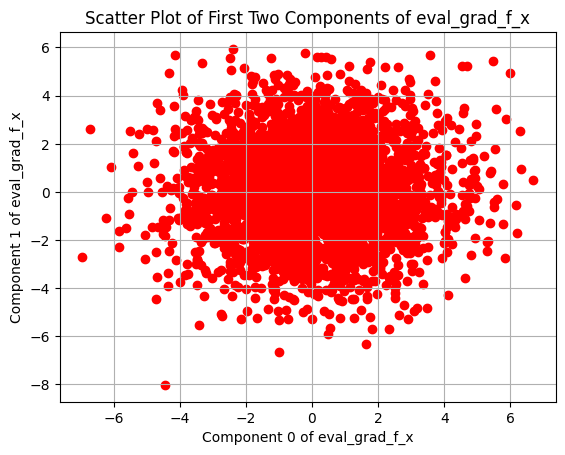

Residual along axis 0 @ value = 0: 0.04527242109179497


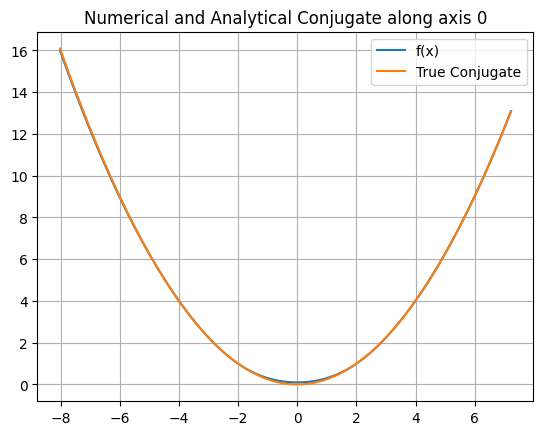

Residual along axis 1 @ value = 0: 0.05617073178291321


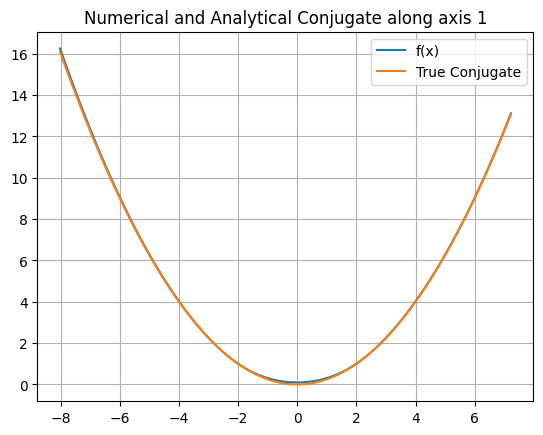

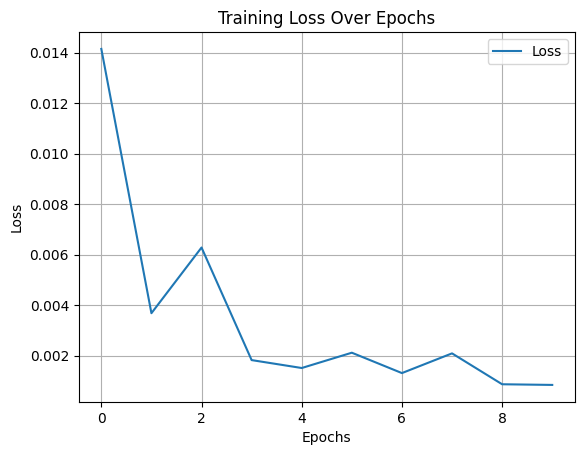

In [ ]:
const_val = 0
# plot section to verify:
plot_results(d, eval_grad_f_x, preds, vmap_f_star_true, state, const_val, Loss)


In [ ]:
eval_batch_x, eval_y, eval_grad_f_x = get_next_batch(train_x)
preds = jnp.squeeze(state.apply_fn({'params': state.params}, eval_grad_f_x)).reshape(-1, 1)
accuracy,acc_max, residual, mre = calculate_statistics(eval_batch_x, eval_grad_f_x, preds, vmap_f_star_true, loss_value)
print("Accuracy:", accuracy)
print("Accuracy max norm:", acc_max)
print("Accuracy, rel:", mre)
print("Residual:", residual)

Accuracy: 0.03145323
Accuracy max norm: 0.31620598
Accuracy, rel: 0.005604658
Residual: 0.027689507
